### Problem Statement

Developed a Country Intelligence and Socio-Economic Segmentation System using advanced machine learning techniques to analyze global development indicators and identify high-priority countries requiring humanitarian aid. Implemented data preprocessing, feature engineering, dimensionality reduction (PCA), clustering algorithms (K-Means, DBSCAN), and supervised ensemble learning models (Random Forest, XGBoost) to achieve high predictive performance and actionable socio-economic insights. Evaluated model performance using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Silhouette Score for robust analytical decision-making.

### STEP 1 — IMPORT LIBRARIES

In [110]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    silhouette_score
)

### STEP 2 — LOAD DATASET

In [111]:
df = pd.read_csv("Country-data.csv")

print(df.shape)

df.head()

(167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


### STEP 3 — DATA UNDERSTANDING

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


### STEP 4 — CHECK MISSING VALUES

In [113]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

### STEP 5 — DATA PREPROCESSING

In [114]:
country_names = df["country"]

X = df.drop(columns=["country"])

# Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Data Scaling Completed")

Data Scaling Completed


### STEP 6 — APPLY PCA

In [115]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("Total Variance Explained:")
print(np.sum(pca.explained_variance_ratio_))

Explained Variance Ratio:
[0.4595174  0.17181626]
Total Variance Explained:
0.6313336543771411


### STEP 7 — FIND OPTIMAL K VALUE

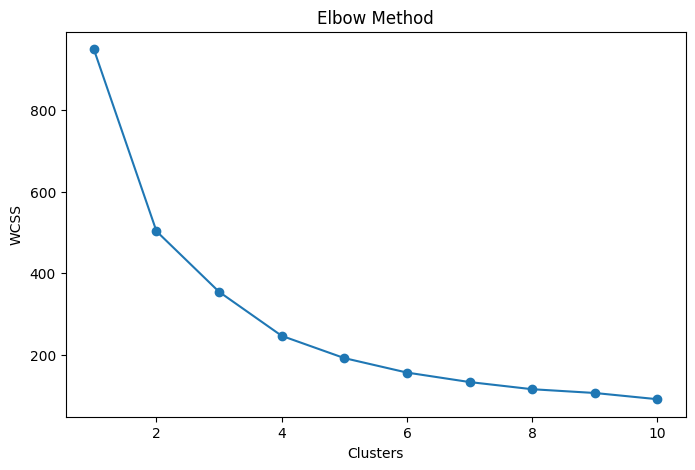

In [116]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_pca)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")

plt.show()

### STEP 8 — APPLY K-MEANS

In [117]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_pca)

print("K-Means Completed")

K-Means Completed


### STEP 9 — SILHOUETTE SCORE

In [118]:
silhouette = silhouette_score(X_pca, cluster_labels)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.4416299354904198


### STEP 9B — APPLY DBSCAN (COMPARISON)
Applying DBSCAN to compare its performance with K-Means. K-Means will be used as the final clustering algorithm due to better segmentation logic for this dataset.

In [119]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_pca)

if len(set(dbscan_labels)) > 1:
    dbscan_silhouette = silhouette_score(X_pca, dbscan_labels)
    print("DBSCAN Silhouette Score:", dbscan_silhouette)
else:
    print("DBSCAN resulted in a single cluster (or only noise). Parameter tuning may be required.")

DBSCAN Silhouette Score: 0.17182026890770916


### STEP 10 — VISUALIZE CLUSTERS

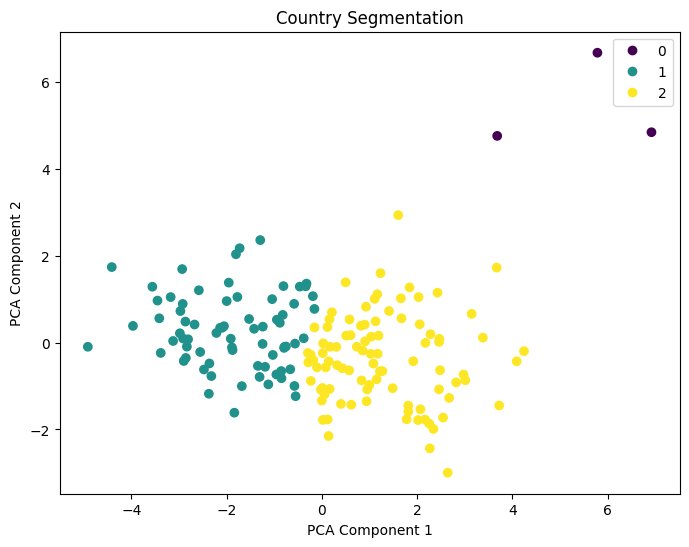

In [120]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=cluster_labels
)

plt.title("Country Segmentation")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.legend(*scatter.legend_elements())

plt.show()

### STEP 11 — CREATE TARGET COLUMN

In [121]:
df["Target"] = cluster_labels

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Target
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


### STEP 12 — MORE VISUALIZATIONS
We will visualize the clusters based on original key features to understand the characteristics of each cluster.

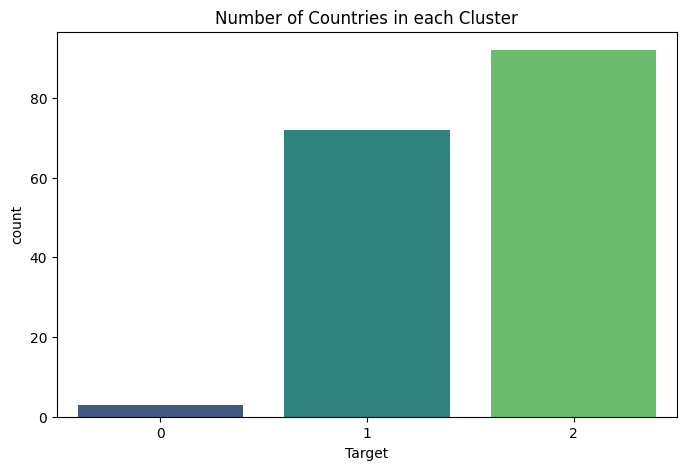

In [122]:
import seaborn as sns

# Add cluster labels to the original dataframe

# Plot cluster distribution
plt.figure(figsize=(8,5))
sns.countplot(x='Target', data=df, palette='viridis')
plt.title('Number of Countries in each Cluster')
plt.show()

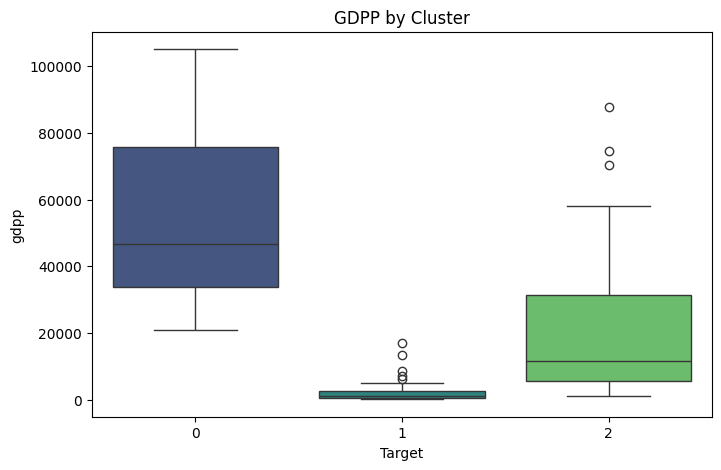

In [123]:
# Boxplot of GDPP vs Cluster
plt.figure(figsize=(8,5))
sns.boxplot(x='Target', y='gdpp', data=df, palette='viridis')
plt.title('GDPP by Cluster')
plt.show()

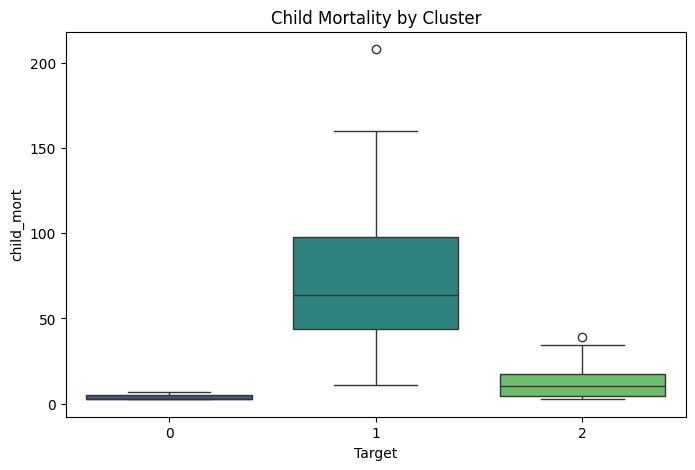

In [124]:
# Boxplot of Child Mortality vs Cluster
plt.figure(figsize=(8,5))
sns.boxplot(x='Target', y='child_mort', data=df, palette='viridis')
plt.title('Child Mortality by Cluster')
plt.show()

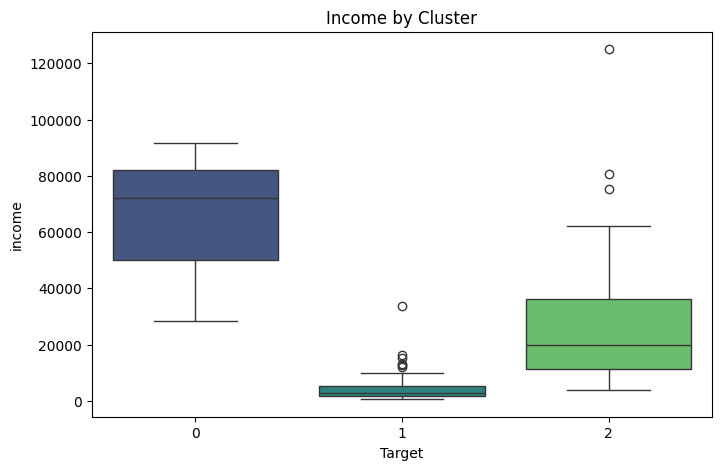

In [125]:
# Boxplot of Income vs Cluster
plt.figure(figsize=(8,5))
sns.boxplot(x='Target', y='income', data=df, palette='viridis')
plt.title('Income by Cluster')
plt.show()

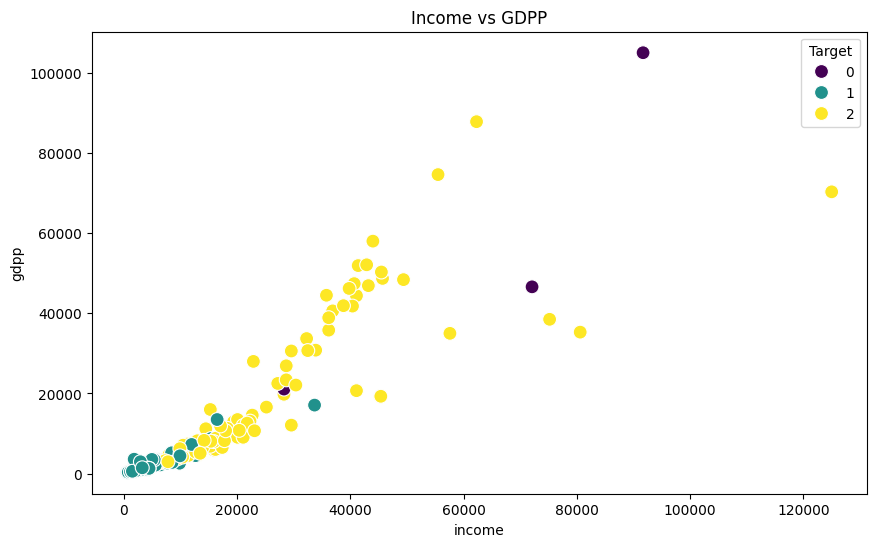

In [126]:
# Scatter plot of Income vs GDPP colored by Cluster
plt.figure(figsize=(10,6))
sns.scatterplot(x='income', y='gdpp', hue='Target', data=df, palette='viridis', s=100)
plt.title('Income vs GDPP')
plt.show()

### STEP 13 — TRAIN TEST SPLIT

In [127]:
X = df.drop(columns=["country", "Target"])

y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### STEP 14 — RANDOM FOREST MODEL

In [128]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [129]:
print("===== RANDOM FOREST RESULTS =====")

print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print("Precision:",
      precision_score(y_test, rf_pred, average='weighted'))

print("Recall:",
      recall_score(y_test, rf_pred, average='weighted'))

print("F1 Score:",
      f1_score(y_test, rf_pred, average='weighted'))

===== RANDOM FOREST RESULTS =====
Accuracy: 0.8529411764705882
Precision: 0.855187908496732
Recall: 0.8529411764705882
F1 Score: 0.8533258115800811


### STEP 15 — XGBOOST MODEL

In [130]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [131]:
print("===== XGBOOST RESULTS =====")

print("Accuracy:",
      accuracy_score(y_test, xgb_pred))

print("Precision:",
      precision_score(y_test, xgb_pred, average='weighted'))

print("Recall:",
      recall_score(y_test, xgb_pred, average='weighted'))

print("F1 Score:",
      f1_score(y_test, xgb_pred, average='weighted'))

===== XGBOOST RESULTS =====
Accuracy: 0.8529411764705882
Precision: 0.855187908496732
Recall: 0.8529411764705882
F1 Score: 0.8533258115800811


### STEP 16 — CLASSIFICATION REPORT

In [132]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           1       0.81      0.87      0.84        15
           2       0.89      0.84      0.86        19

    accuracy                           0.85        34
   macro avg       0.85      0.85      0.85        34
weighted avg       0.86      0.85      0.85        34



### STEP 17 — FEATURE IMPORTANCE

In [133]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
0,child_mort,0.657959
1,exports,0.100681
3,imports,0.098181
6,life_expec,0.030805
7,total_fer,0.026265
4,income,0.025774
8,gdpp,0.024558
5,inflation,0.019837
2,health,0.015940


### STEP 18 — VISUALIZE FEATURE IMPORTANCE

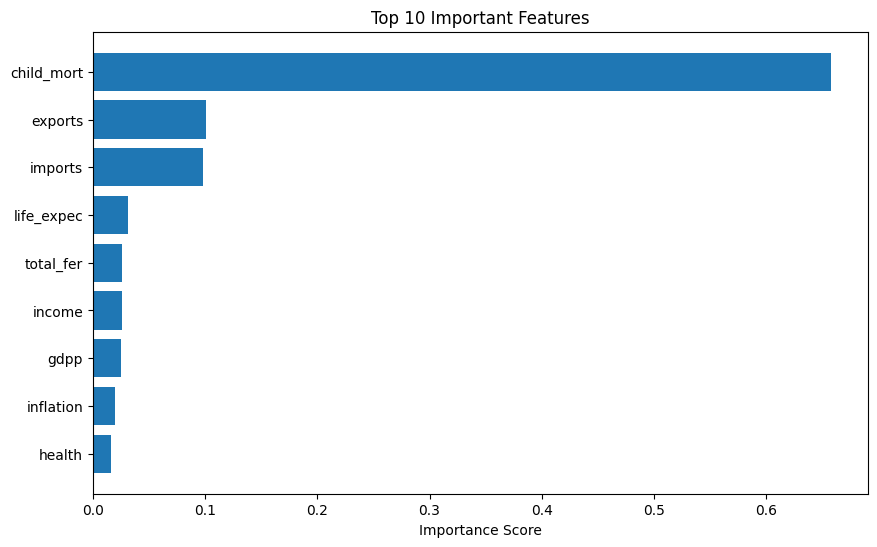

In [134]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.title("Top 10 Important Features")

plt.xlabel("Importance Score")

plt.gca().invert_yaxis()

plt.show()

### STEP 19 — SAVE FINAL RESULTS

In [135]:
df["Predicted_Cluster"] = xgb.predict(X)

df.to_csv(
    "final_country_segmentation_results.csv",
    index=False
)

print("Project Completed Successfully")

Project Completed Successfully
